In [1]:
import random
from copy import deepcopy
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


class TrainingData:
    def __init__(self, X, y):
        self._X = deepcopy(X)
        self._y = deepcopy(y)

    def append(self, x, y):
        self._X.append(x)
        self._y.append(y)

    @property
    def X(self):
        return self._X

    @property
    def y(self):
        return self._y

class RAL:
    def __init__(self, committee_classifiers, threshold_uncertainty, threshold_greedy, eta, reward=1, penalty=-1,
                 budget=None, model_update_frequency=1):
        self._committee_classifiers = deepcopy(committee_classifiers)
        self._threshold_uncertainty = threshold_uncertainty
        self._threshold_greedy = threshold_greedy
        self._eta = eta
        self._reward = reward
        self._penalty = penalty
        self._budget = budget
        self._model_update_frequency = model_update_frequency

        self._committee_classifier = VotingClassifier(
            list(zip(map(str, range(len(committee_classifiers))), self._committee_classifiers)), voting='soft')

        self._alpha = [1.0 / len(self._committee_classifiers) for _ in range(len(self._committee_classifiers))]
        self._state = False
        self._n_acquired_samples = 0
        self._training_data_samples = None
        self._n_committee_too_low_acquires = 0
        self._n_committee_acquires = 0
        self._n_greedy_acquires = 0
        self._n_both_acquires = 0
        self._n_seen = 0
        self._alphas = [deepcopy(self._alpha)]

    @property
    def alphas(self):
        return self._alphas

    @property
    def n_committee_too_low_acquires(self):
        return self._n_committee_too_low_acquires

    @property
    def n_greedy_acquires(self):
        return self._n_greedy_acquires

    @property
    def n_committee_acquires(self):
        return self._n_committee_acquires

    @property
    def n_both_acquires(self):
        return self._n_both_acquires

    def fit(self, X, y):
        if self._state:
            raise AssertionError('fit has already been called.')
        self._training_data_samples = TrainingData(list(X), list(y))
        for learner in self._committee_classifiers:
            learner.fit(X, y)
        self._committee_classifier.fit(X, y)
        self._state = True

    def reward(self, y_true, y_predicted):
        if y_true != y_predicted:
            return self._reward
        else:
            return self._penalty

    def _update_alpha(self, reward, decisions, committee_decision):
        for idx, decision in enumerate(decisions):
            if int(decision) == int(committee_decision):
                self._alpha[idx] = self._alpha[idx] * np.exp(reward * self._eta)
        s = sum(self._alpha)
        for idx, coef in enumerate(self._alpha):
            self._alpha[idx] = float(coef) / s
        self._alphas.append(deepcopy(self._alpha))

    def _update_uncertainty_threshold(self, reward):
        f_reward = self._eta * (1. - np.power(2.0, float(reward) / self._penalty))
        self._threshold_uncertainty = min(self._threshold_uncertainty * (1. + f_reward), 1.)

    def _has_enough_budget(self):
        if self._budget is None:
            return True
        return float(self._n_acquired_samples) / self._n_seen < self._budget

    def ask_committee(self, x):
        decisions = []
        for learner in self._committee_classifiers:
            decisions.append(np.max(learner.predict_proba(x.reshape(1, -1))) < self._threshold_uncertainty)
        committee_decision = bool(round(sum([self._alpha[idx] * el for idx, el in enumerate(decisions)])))
        return committee_decision, decisions

    def should_label(self, committee_decision):
        self._n_seen += 1
        if not self._has_enough_budget():
            if committee_decision:
                self._n_committee_too_low_acquires += 1
            return False
        if committee_decision:
            self._n_committee_acquires += 1
        if random.random() < self._threshold_greedy:
            self._n_greedy_acquires += 1
            if committee_decision:
                self._n_both_acquires += 1
            return True
        else:
            return committee_decision

    def acquire_label(self, x, y, committee_decision, decisions):
        if committee_decision:
            yp = self._committee_classifier.predict(x.reshape(1, -1))[0]
            reward = self.reward(y, yp)
            self._update_alpha(reward, decisions, committee_decision)
            self._update_uncertainty_threshold(reward)
        self._n_acquired_samples += 1
        self._training_data_samples.append(x, y)
        if self._n_acquired_samples % self._model_update_frequency == 0:
            for learner in self._committee_classifiers:
                learner.fit(self._training_data_samples.X, self._training_data_samples.y)
            self._committee_classifier.fit(self._training_data_samples.X, self._training_data_samples.y)

    def evaluate_metrics(self, X, y):
        self._committee_classifier.fit(self._training_data_samples.X, self._training_data_samples.y)
        y_pred = self._committee_classifier.predict(X)
        accuracy = accuracy_score(y, y_pred)
        precision = precision_score(y, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y, y_pred, average='weighted', zero_division=0)
        return {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'y_pred': y_pred
        }

def main(attack_type, perturbation_levels):
    # Parameters
    THRESHOLD_GREEDY = 0.025
    THRESHOLD_UNCERTAINTY = 0.9
    ETA = 0.01
    REWARD = 1
    PENALTY = -1
    BUDGET = 0.2
    MODEL_UPDATE_FREQUENCY = 1

    # Data paths
    dataset_path = 'Dataset'  # Replace with actual dataset path
    base_path = 'Dataset'  # Replace with actual adversarial data path
    csv_filename='IUST_MSCN_original.csv'
    # Load base datasets
    original_df = pd.read_csv(f'{dataset_path}/{csv_filename}')
    
    # تقسیم داده به train (60%)، validation (20%)، test (20%)
    train_df, temp_df = train_test_split(original_df, test_size=0.4, random_state=42)
    val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)


    # Prepare data
    X_train = train_df.iloc[:, :-1].values
    y_train = train_df.iloc[:, -1].values
    X_val = val_df.iloc[:, :-1].values
    y_val = val_df.iloc[:, -1].values
    X_test = test_df.iloc[:, :-1].values
    y_test = test_df.iloc[:, -1].values

    # Define committee classifiers
    knn = KNeighborsClassifier()
    rf10 = RandomForestClassifier()
    dt = DecisionTreeClassifier()
    learners = [knn, rf10, dt]

    # Create and train RAL model
    ral = RAL(learners, THRESHOLD_UNCERTAINTY, THRESHOLD_GREEDY, ETA, reward=REWARD, penalty=PENALTY, budget=BUDGET,
              model_update_frequency=MODEL_UPDATE_FREQUENCY)
    ral.fit(X_train, y_train)

    # Evaluate initial performance on validation and test sets
    init_val_metrics = ral.evaluate_metrics(X_val, y_val)
    print(f"Initial Validation Accuracy: {init_val_metrics['accuracy']:.4f}")
    init_test_metrics = ral.evaluate_metrics(X_test, y_test)
    print(f"Initial Test Accuracy: {init_test_metrics['accuracy']:.4f}")

    # Test on perturbed datasets
    results = []
    cumulative_data = {}  # For plotting cumulative accuracy

    for train_perturb_level in perturbation_levels:
        try:
            df = pd.read_csv(f'{base_path}/{attack_type}/{attack_type}_eps_{train_perturb_level}.csv')
            X_perturb = df.iloc[:, :-1].values
            y_perturb = df.iloc[:, -1].values
            print(f"Loaded data for perturbation level {train_perturb_level} with {X_perturb.shape[0]} samples.")
            
            # Evaluate metrics on perturbed data
            metrics = ral.evaluate_metrics(X_perturb, y_perturb)
            print(f"Accuracy for perturbation level {train_perturb_level}: {metrics['accuracy']:.4f}")
            
            # Store results
            results.append({
                'perturbation_level': train_perturb_level,
                'accuracy': metrics['accuracy'],
                'precision': metrics['precision'],
                'recall': metrics['recall'],
                'f1': metrics['f1'],
                'n_samples': X_perturb.shape[0]
            })
            
            # Calculate cumulative accuracy for this level
            y_pred = metrics['y_pred']
            cumulative_acc = []
            for i in range(1, len(y_perturb) + 1):
                acc = accuracy_score(y_perturb[:i], y_pred[:i])
                cumulative_acc.append(acc)
            cumulative_data[train_perturb_level] = {
                'samples': list(range(1, len(y_perturb) + 1)),
                'cumulative_acc': cumulative_acc
            }
            
        except FileNotFoundError:
            print(f"Error: File for perturbation level {train_perturb_level} not found.")
            continue

    # Display results table
    results_df = pd.DataFrame(results)
    print("\nSummary of Results:")
    print(results_df.round(4).to_string(index=False))

    # Plot cumulative accuracy vs number of samples for each perturbation level
    plt.figure(figsize=(12, 8))
    colors = plt.cm.viridis(np.linspace(0, 1, len(cumulative_data)))
    for idx, (level, data) in enumerate(cumulative_data.items()):
        plt.plot(data['samples'], data['cumulative_acc'], 
                label=f'Perturbation Level {level}', color=colors[idx], linewidth=2)
    plt.xlabel('Number of Samples')
    plt.ylabel('Cumulative Accuracy')
    plt.title('Cumulative Accuracy vs. Number of Samples for Different Perturbation Levels')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Initial Validation Accuracy: 0.9229
Initial Test Accuracy: 0.9300
Loaded data for perturbation level 0.01 with 1428 samples.
Accuracy for perturbation level 0.01: 0.8655
Loaded data for perturbation level 0.05 with 1428 samples.
Accuracy for perturbation level 0.05: 0.6667
Loaded data for perturbation level 0.1 with 1428 samples.
Accuracy for perturbation level 0.1: 0.5308
Loaded data for perturbation level 0.2 with 1428 samples.
Accuracy for perturbation level 0.2: 0.4314
Loaded data for perturbation level 0.5 with 1428 samples.
Accuracy for perturbation level 0.5: 0.3775

Summary of Results:
 perturbation_level  accuracy  precision  recall     f1  n_samples
               0.01    0.8655     0.8714  0.8655 0.8644       1428
               0.05    0.6667     0.6790  0.6667 0.6650       1428
               0.10    0.5308     0.6063  0.5308 0.5125       1428
               0.20    0.4314     0.4861  0.4314 0.4253       1428
               0.50    0.3775     0.4364  0.3775 0.3741       14

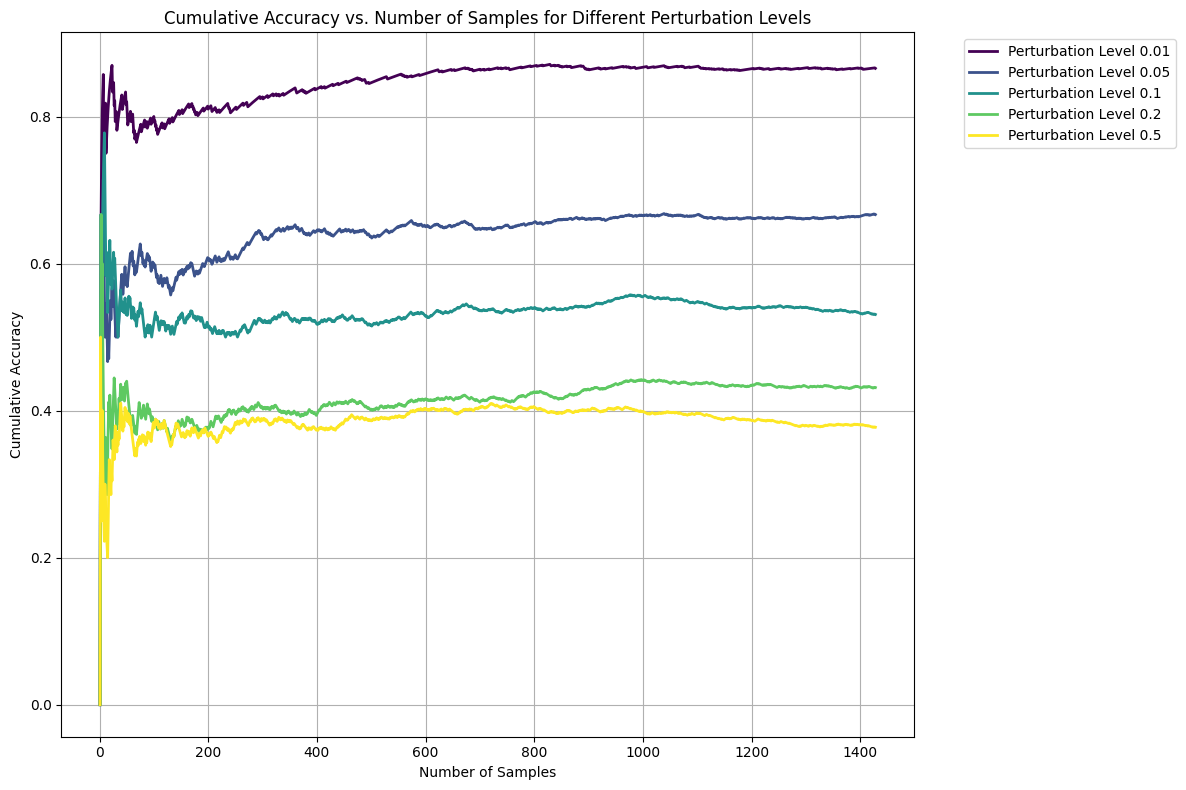

In [2]:
if __name__ == "__main__":
    test_perturb_levels = [0.01, 0.05, 0.1, 0.2, 0.5]
    attack_type = 'FGSM'
    main(attack_type, test_perturb_levels)

Initial Validation Accuracy: 0.9208
Initial Test Accuracy: 0.9349
Loaded data for perturbation level 0.01 with 1428 samples.
Accuracy for perturbation level 0.01: 0.8592
Loaded data for perturbation level 0.05 with 1428 samples.
Accuracy for perturbation level 0.05: 0.7283
Loaded data for perturbation level 0.1 with 1428 samples.
Accuracy for perturbation level 0.1: 0.6443
Loaded data for perturbation level 0.2 with 1428 samples.
Accuracy for perturbation level 0.2: 0.5406
Loaded data for perturbation level 0.5 with 1428 samples.
Accuracy for perturbation level 0.5: 0.6204

Summary of Results:
 perturbation_level  accuracy  precision  recall     f1  n_samples
               0.01    0.8592     0.8772  0.8592 0.8515       1428
               0.05    0.7283     0.7409  0.7283 0.7204       1428
               0.10    0.6443     0.6621  0.6443 0.6302       1428
               0.20    0.5406     0.5700  0.5406 0.5416       1428
               0.50    0.6204     0.6246  0.6204 0.6139       14

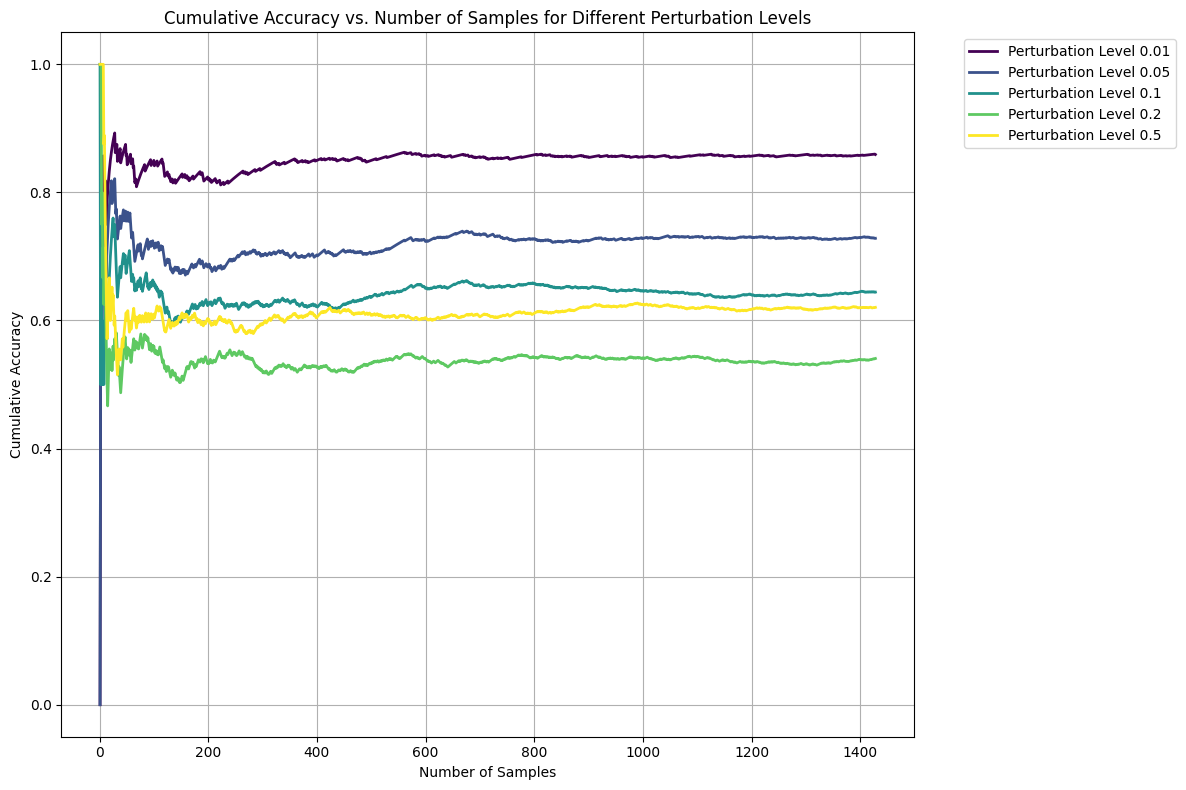

In [3]:
if __name__ == "__main__":
    test_perturb_levels = [0.01, 0.05, 0.1, 0.2, 0.5]
    attack_type = 'PGD'
    main(attack_type, test_perturb_levels)

Initial Validation Accuracy: 0.9222
Initial Test Accuracy: 0.9335
Loaded data for perturbation level 0.1 with 1428 samples.
Accuracy for perturbation level 0.1: 0.9615
Loaded data for perturbation level 0.5 with 1428 samples.
Accuracy for perturbation level 0.5: 0.8761
Loaded data for perturbation level 1.0 with 1428 samples.
Accuracy for perturbation level 1.0: 0.7437
Loaded data for perturbation level 2.0 with 1428 samples.
Accuracy for perturbation level 2.0: 0.6604
Loaded data for perturbation level 5.0 with 1428 samples.
Accuracy for perturbation level 5.0: 0.7577

Summary of Results:
 perturbation_level  accuracy  precision  recall     f1  n_samples
                0.1    0.9615     0.9626  0.9615 0.9617       1428
                0.5    0.8761     0.8829  0.8761 0.8750       1428
                1.0    0.7437     0.7480  0.7437 0.7403       1428
                2.0    0.6604     0.6641  0.6604 0.6592       1428
                5.0    0.7577     0.7721  0.7577 0.7393       1428


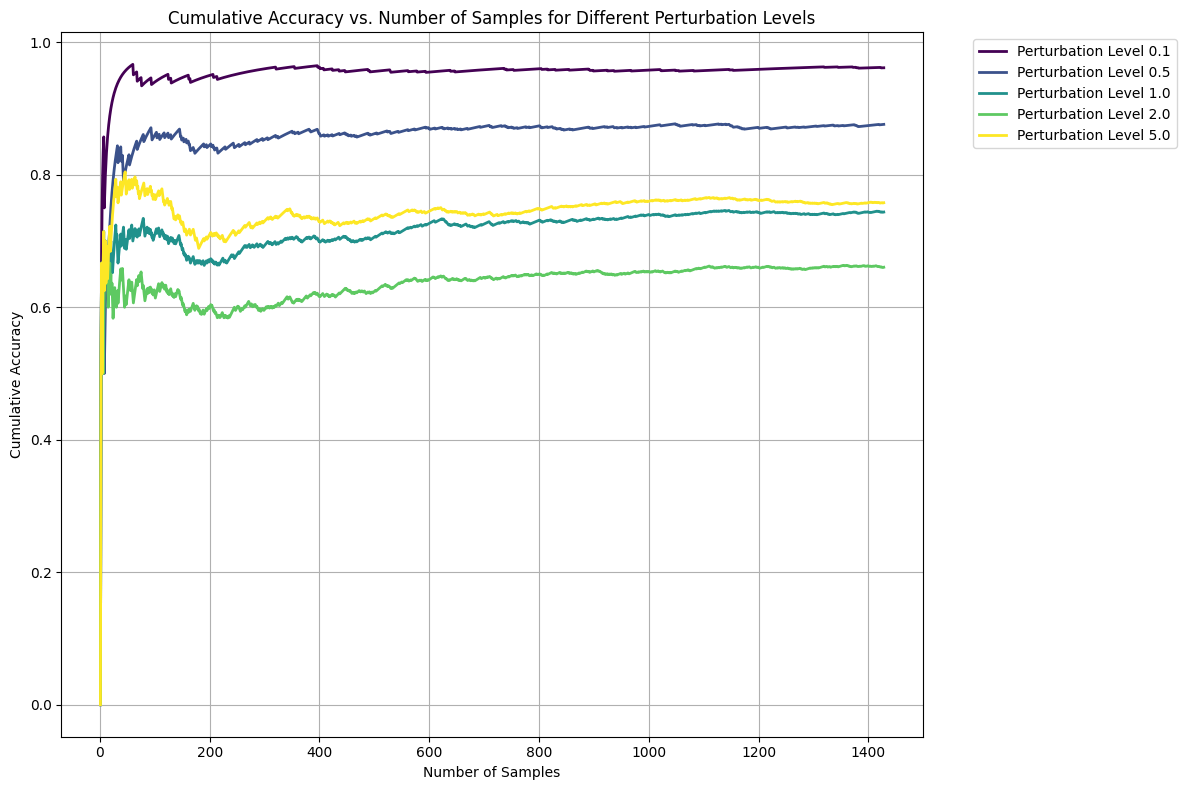

In [4]:
if __name__ == "__main__":
    test_perturb_levels = [0.1, 0.5, 1.0, 2.0, 5.0]
    attack_type = 'CW'
    main(attack_type, test_perturb_levels)

Initial Validation Accuracy: 0.9201
Initial Test Accuracy: 0.9363
Loaded data for perturbation level 0.1 with 1428 samples.
Accuracy for perturbation level 0.1: 0.8761
Loaded data for perturbation level 0.5 with 1428 samples.
Accuracy for perturbation level 0.5: 0.8004
Loaded data for perturbation level 1.0 with 1428 samples.
Accuracy for perturbation level 1.0: 0.7647
Loaded data for perturbation level 2.0 with 1428 samples.
Accuracy for perturbation level 2.0: 0.6709
Loaded data for perturbation level 5.0 with 1428 samples.
Accuracy for perturbation level 5.0: 0.6436

Summary of Results:
 perturbation_level  accuracy  precision  recall     f1  n_samples
                0.1    0.8761     0.8866  0.8761 0.8735       1428
                0.5    0.8004     0.8119  0.8004 0.7940       1428
                1.0    0.7647     0.7736  0.7647 0.7565       1428
                2.0    0.6709     0.6707  0.6709 0.6627       1428
                5.0    0.6436     0.6383  0.6436 0.6373       1428


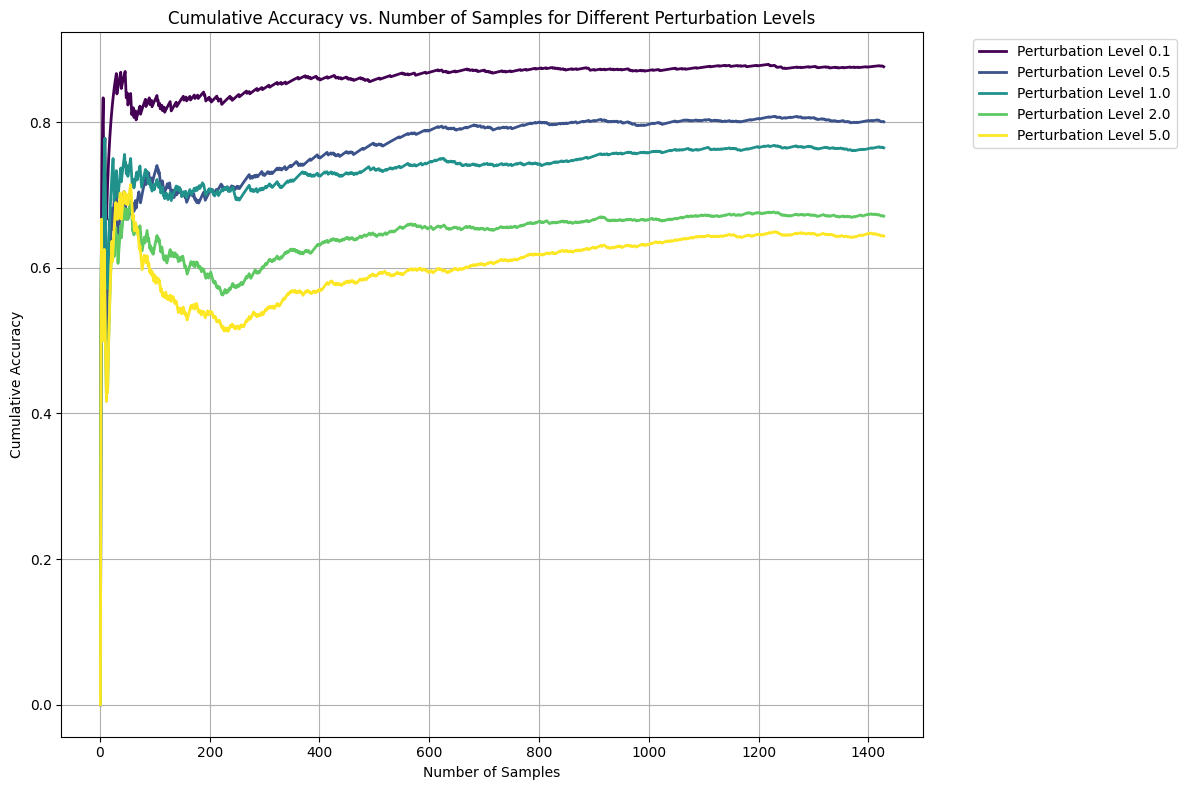

In [5]:
if __name__ == "__main__":
    test_perturb_levels = [0.1, 0.5, 1.0, 2.0, 5.0]
    attack_type = 'DeepFool'
    main(attack_type, test_perturb_levels)